In [1]:




import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score,
                             classification_report, ConfusionMatrixDisplay)

## 2. Load the Preprocessed Dataset
This cell loads the cleaned and scaled dataset from the preprocessing stage. The data is divided into training and test sets using the existing `split` column. The `denied` column is the target, and the remaining 25 columns are the features. The output shows 283,879 training rows and 70,970 test rows, and that only 6.9% of applications are denied, so the dataset is highly imbalanced.

In [2]:
PATH = '/content/final_processed.csv.gz'
df = pd.read_csv(PATH, compression='gzip')

train = df[df['split'] == 'train']
test = df[df['split'] == 'test']

X_train = train.drop(columns=['denied', 'split'])
y_train = train['denied']
X_test = test.drop(columns=['denied', 'split'])
y_test = test['denied']

print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))

(283879, 25) (70970, 25)
denied
0    0.93089
1    0.06911
Name: proportion, dtype: float64


## 3. Evaluation Function
This cell defines a helper function that trains a model, predicts on the test set and stores six metrics: Accuracy, Precision, Recall, F1, ROC-AUC and PR-AUC. Every model variety is evaluated on the same test set so the results can be compared fairly. Because the data is imbalanced, F1, Recall and PR-AUC are more meaningful than Accuracy.

In [4]:
results = []

def evaluate(name, model, X_tr, y_tr):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1': f1_score(y_test, pred),
        'ROC-AUC': roc_auc_score(y_test, prob),
        'PR-AUC': average_precision_score(y_test, prob)
    })
    return model

## 4. Model Varieties (Manual Tuning)
This cell trains four varieties of the Decision Tree:
1. Baseline: default settings, the tree grows to full depth.
2. max_depth=10: the depth is limited to reduce overfitting.
3. Balanced: `class_weight='balanced'` gives more weight to the denied class.
4. Undersampled: the training data is balanced by keeping all denied rows and an equal number of not denied rows.

The results show a trade-off: limiting the depth gives high precision but low recall, while balancing the classes gives high recall but low precision.

In [5]:
evaluate('DT Baseline', DecisionTreeClassifier(random_state=42), X_train, y_train)

evaluate('DT max_depth=10', DecisionTreeClassifier(max_depth=10, random_state=42), X_train, y_train)

evaluate('DT Balanced depth=10',
         DecisionTreeClassifier(max_depth=10, class_weight='balanced', random_state=42),
         X_train, y_train)

pos = train[train['denied'] == 1]
neg = train[train['denied'] == 0].sample(len(pos), random_state=42)
under = pd.concat([pos, neg]).sample(frac=1, random_state=42)
X_under = under.drop(columns=['denied', 'split'])
y_under = under['denied']

evaluate('DT Undersampled depth=10',
         DecisionTreeClassifier(max_depth=10, random_state=42),
         X_under, y_under)

pd.DataFrame(results)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,DT Baseline,0.910554,0.354095,0.356983,0.355533,0.674506,0.180523
1,DT max_depth=10,0.940609,0.839567,0.173904,0.288127,0.800560,0.381374
2,DT Balanced depth=10,0.732070,0.163663,0.699898,0.265291,0.801527,0.374778
3,DT Undersampled depth=10,0.738101,0.165215,0.688277,0.266467,0.794203,0.283922


## 5. Hyperparameter Tuning with GridSearchCV
This cell searches 60 combinations of `criterion`, `max_depth`, `min_samples_leaf` and `class_weight` using 3-fold stratified cross validation (180 fits in total). Stratified folds keep the same class ratio in every fold. The F1 score is used to select the best combination. The best parameters found were criterion = entropy, max_depth = 20, min_samples_leaf = 1 and class_weight = None, with a cross validation F1 of 0.369.

In [6]:
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_leaf': [1, 20, 100],
    'class_weight': [None, 'balanced']
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
grid = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid,
                    scoring='f1', cv=cv, n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

Fitting 3 folds for each of 60 candidates, totalling 180 fits
{'class_weight': None, 'criterion': 'entropy', 'max_depth': 20, 'min_samples_leaf': 1}
0.3691666487150969


## 6. Final Tuned Model and Comparison Table
This cell trains the final model using the best hyperparameters from GridSearchCV and adds it to the results. The table compares all five varieties on the test set. The tuned model achieves the highest F1 score (0.3593) with a precision of 0.5298 and a recall of 0.2718.

In [7]:
best = evaluate('DT GridSearch Best', DecisionTreeClassifier(**grid.best_params_, random_state=42),
                X_train, y_train)

res = pd.DataFrame(results).round(4)
res

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,DT Baseline,0.9106,0.3541,0.3570,0.3555,0.6745,0.1805
1,DT max_depth=10,0.9406,0.8396,0.1739,0.2881,0.8006,0.3814
2,DT Balanced depth=10,0.7321,0.1637,0.6999,0.2653,0.8015,0.3748
3,DT Undersampled depth=10,0.7381,0.1652,0.6883,0.2665,0.7942,0.2839
4,DT GridSearch Best,0.9330,0.5298,0.2718,0.3593,0.7548,0.3025


## 7. Comparison Chart
This cell plots Precision, Recall, F1 and PR-AUC for all five varieties as a bar chart, which makes the precision and recall trade-off between the varieties easy to see.

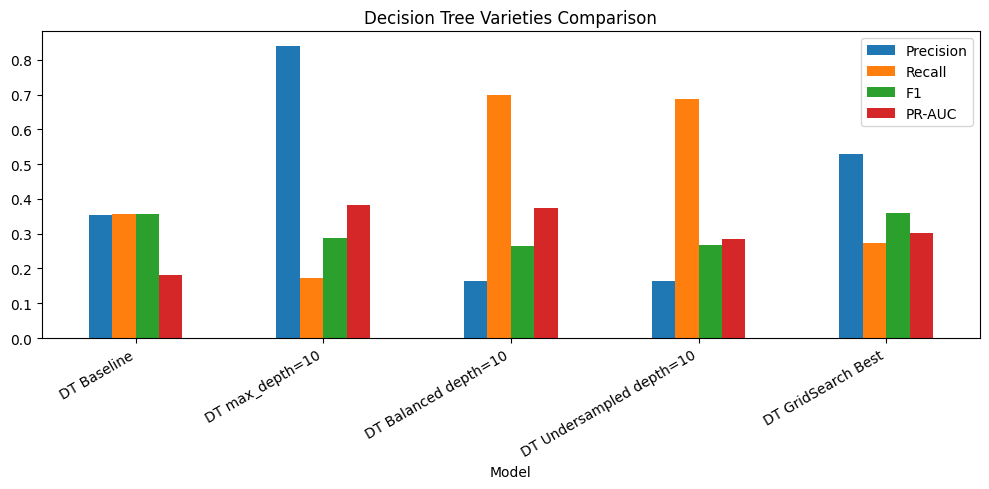

In [8]:
res.set_index('Model')[['Precision', 'Recall', 'F1', 'PR-AUC']].plot(kind='bar', figsize=(10, 5))
plt.title('Decision Tree Varieties Comparison')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 8. Best Model: Classification Report and Confusion Matrix
This cell shows the detailed performance of the best model for each class. The confusion matrix shows how many applications were correctly and incorrectly predicted as denied or not denied.

              precision    recall  f1-score   support

  Not Denied       0.95      0.98      0.96     66065
      Denied       0.53      0.27      0.36      4905

    accuracy                           0.93     70970
   macro avg       0.74      0.63      0.66     70970
weighted avg       0.92      0.93      0.92     70970



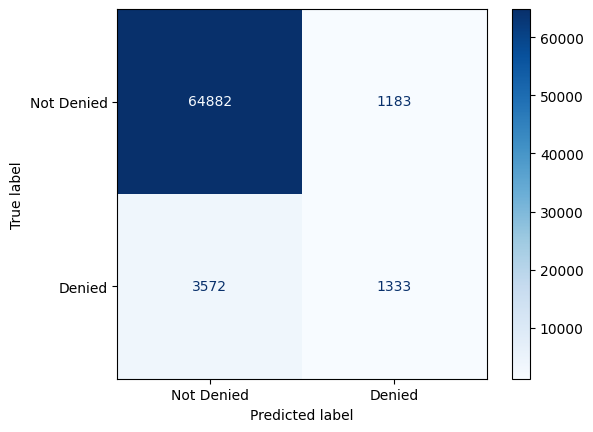

In [9]:
pred = best.predict(X_test)
print(classification_report(y_test, pred, target_names=['Not Denied', 'Denied']))

ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=['Not Denied', 'Denied'], cmap='Blues')
plt.show()

## 9. Feature Importance and Tree Visualisation
This cell shows the 15 features that the tree used most when making decisions, and draws the top three levels of the tree. The first split is on `wage_offer_annual`, which shows that the offered wage is the most important factor. Applications with a low wage offer, an unknown prevailing wage source or no agent are denied more often.

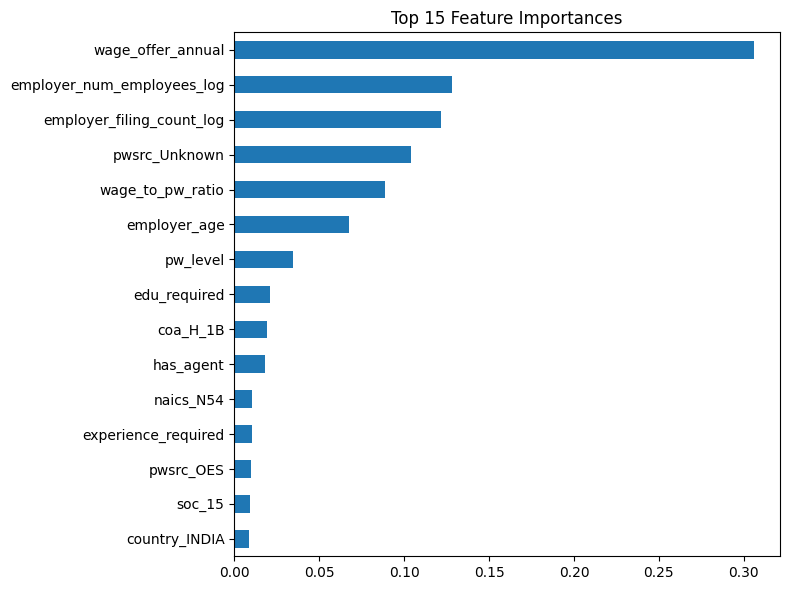

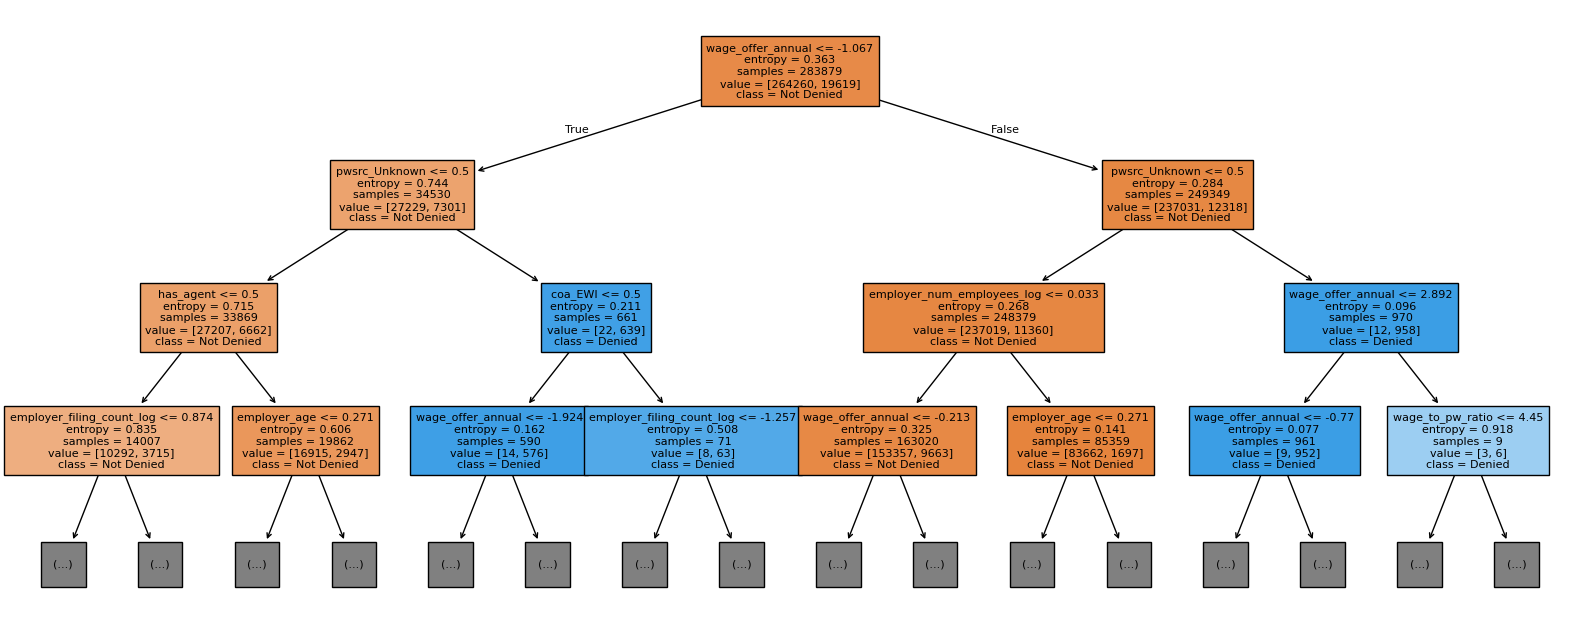

In [10]:
imp = pd.Series(best.feature_importances_, index=X_train.columns).sort_values().tail(15)
imp.plot(kind='barh', figsize=(8, 6))
plt.title('Top 15 Feature Importances')
plt.tight_layout()
plt.show()

plt.figure(figsize=(20, 8))
plot_tree(best, max_depth=3, feature_names=X_train.columns, class_names=['Not Denied', 'Denied'],
          filled=True, fontsize=8)
plt.show()